In [4]:
! pip install -u sentence-transformers


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -u


In [5]:
from sentence_transformers import SentenceTransformer
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [6]:
model = SentenceTransformer("clip-ViT-B-32")

modules.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/1.91k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.03k [00:00<?, ?B/s]

0_CLIPModel/model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

...

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/604 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

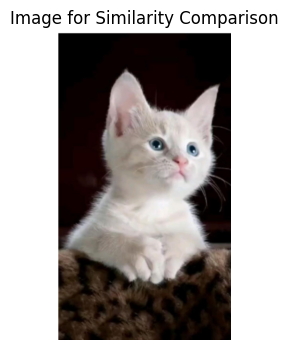

In [7]:
path1 = "/content/WhatsApp Image 2026-09-17 at 21.20.51.jpeg"
i1 = Image.open(path1)
plt.figure(figsize = (4,4))
plt.imshow(i1)
plt.axis("off")
plt.title("Image for Similarity Comparison")
plt.show()

In [8]:
text_description = ["Two dogs in the snow",
                    "A cat on a table",
                    "A picture of london at night",
                    "A happy dog playing fetch",
                    "A dog sleeping on a couch",
                    "Two cats fighting in a garden",
                    "An ice seller on road"]

In [9]:
def compare_image(image_path,text_description):
  img = Image.open(image_path)

  text_emb = model.encode(text_description)
  img_emb = model.encode(img)

  similarity_score = np.dot(text_emb,img_emb)

  best_match_index = np.argmax(similarity_score)
  best_match_desc = text_description[best_match_index]
  print(f"\nBest match for the image is {best_match_desc} with score of {similarity_score.max()}")
  # Display the image
  plt.figure(figsize = (6,6))
  plt.imshow(img)
  plt.axis('off')
  plt.title("Image for similarity comparison",fontsize=14)
  plt.show()

In [10]:
image_path = "/content/WhatsApp Image 2026-09-17 at 21.20.52.jpeg"


Best match for the image is A cat on a table with score of 27.99648666381836


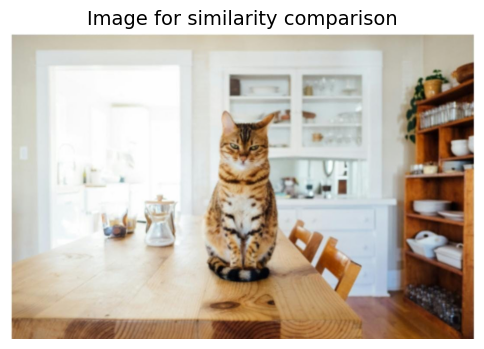

In [11]:
compare_image(image_path,text_description)